In [2]:
from mpi4py import MPI
import gmsh
import numpy as np
import time
from scipy.spatial import cKDTree
import pyvista as pv
from dolfinx import plot

Lx, Ly = 1.0, 1.0

In [3]:
from dolfinx import mesh, fem
import ufl
import numpy as np
from dolfinx.io import gmsh as gmshio
from mpi4py import MPI

# ---------------------------------------------------------------------
# 1. Mesh and tags (same mesh as reference)
# ---------------------------------------------------------------------
ref = 6
filename = f"regular_mesh_{ref}.msh"
msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]

tdim = msh.topology.dim  # 2
fdim = tdim - 1          # 1

lc = 1.0 / (2**ref)      # mesh size
h = lc

omega = msh

# ---------------------------------------------------------------------
# 2. Function space (standard CG on the bulk only)
# ---------------------------------------------------------------------
order = 1
V = fem.functionspace(omega, ("Lagrange", order))

# ---------------------------------------------------------------------
# 3. Trial / Test / Solution function
# ---------------------------------------------------------------------
phi = ufl.TestFunction(V)
p = fem.Function(V, name="p")
dp = ufl.TrialFunction(V)

# ---------------------------------------------------------------------
# 4. Coordinates and data
# ---------------------------------------------------------------------
x = ufl.SpatialCoordinate(omega)
f_m = -x[1]**2 - 2*x[0]**2 - x[0]

def f_callable(x):
    """f = -(y² + 2x² + x)  from -∇·((2x+1)∇p) with p = (x/2)y²."""
    return -x[1]**2 - 2*x[0]**2 - x[0]

f = fem.Function(V)
f_func = fem.Function(V)
f_func.interpolate(f_callable)
f.interpolate(f_callable)

k_m = fem.Function(V, name="kappa")

def k_callable(x):
    vals = 2*x[0] + 1.0
    return vals[np.newaxis, :]

k_m.interpolate(k_callable)

dx = ufl.Measure("dx", domain=omega)

# compute domain bbox to locate sides
coords = omega.geometry.x
xx = coords[:, 0]
yy = coords[:, 1]
xmin, xmax = xx.min(), xx.max()
ymin, ymax = yy.min(), yy.max()

tol = 1e-10 * max(xmax - xmin, ymax - ymin)

# locate boundary facets for bottom (y = ymin) and top (y = ymax)
bottom_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol)
)
top_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol)
)

indices = np.concatenate([bottom_facets, top_facets]).astype(np.int32)
values = np.concatenate([
    np.full(bottom_facets.shape, 10, dtype=np.int32),  # bottom tag = 10
    np.full(top_facets.shape,    20, dtype=np.int32),  # top tag    = 20
])
neumann_tags = mesh.meshtags(omega, fdim, indices, values)

dsN = ufl.Measure("ds", domain=omega, subdomain_data=neumann_tags)
g_top = 2*x[0]**2 + x[0]   # k∇p·n|_{y=1} = (2x+1)·x = 2x²+x
g_bottom = 0.0

# ---------------------------------------------------------------------
# 5. Weak form (standard Darcy / Poisson form)
# ---------------------------------------------------------------------
a = ufl.inner(k_m * ufl.grad(dp), ufl.grad(phi)) * dx
L = f_m * phi * dx
L += g_bottom * phi * dsN(10)
L += g_top * phi * dsN(20)

A_form = ufl.inner(k_m * ufl.grad(dp), ufl.grad(phi)) * dx
b_form = L

# ---------------------------------------------------------------------
# 6. Dirichlet BCs (left/right like reference)
# ---------------------------------------------------------------------
left_dofs   = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmin, atol=tol))
right_dofs  = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmax, atol=tol))
top_dofs    = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[1], ymax, atol=tol))
bottom_dofs = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[1], ymin, atol=tol))

all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))
dof_coords = V.tabulate_dof_coordinates()

p_bc_fun = fem.Function(V)
p_bc_fun.x.array[left_dofs]  = 0.0
p_bc_fun.x.array[right_dofs] = dof_coords[right_dofs, 1]**2 / 2.0

bc = fem.dirichletbc(p_bc_fun, all_dofs)
bcs = [bc]

# ---------------------------------------------------------------------
# 7. Solve linear problem using dolfinx.fem.petsc.LinearProblem
# ---------------------------------------------------------------------
from dolfinx.fem import petsc

linear_problem = petsc.LinearProblem(
    a=A_form,
    L=b_form,
    bcs=bcs,
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "ksp_error_if_not_converged": True,
    },
    petsc_options_prefix="pmix_"
)

cg_solve_start = time.perf_counter()
p_sol = linear_problem.solve()
cg_solve_time = omega.comm.allreduce(time.perf_counter() - cg_solve_start, op=MPI.MAX)
p_sol.name = "pressure"

p.x.array[:] = p_sol.x.array[:]

# ---------------------------------------------------------------------
# 8. Diagnostics
# ---------------------------------------------------------------------
print("DOFs in V:", V.dofmap.index_map.size_global)
print(f"CG solve time: {cg_solve_time:.6f} s")

Info    : Reading 'regular_mesh_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading 'regular_mesh_6.msh'
DOFs in V: 4225
CG solve time: 1.622611 s


In [4]:
# from dolfinx import io

# with io.XDMFFile(omega.comm, "pressure.xdmf", "w") as xdmf:
#     xdmf.write_mesh(omega)
#     xdmf.write_function(p_sol)

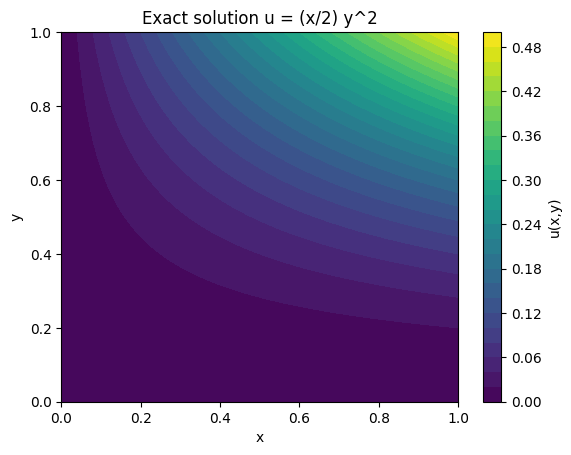

In [5]:
import numpy as np
import matplotlib.pyplot as plt

n = 100
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, y)

U = 0.5 * X * Y**2

plt.figure()
plt.contourf(X, Y, U, levels=30)
plt.colorbar(label="u(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Exact solution u = (x/2) y^2")
plt.show()

In [6]:
# ---------------------------------------------------------------------
# CG convergence analysis for p and q on ref = 2,3,4,5,6,7
# ---------------------------------------------------------------------
import basix
from dolfinx.fem import petsc
import math

def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        if errors[i - 1] > 0 and errors[i] > 0 and hs[i] != hs[i - 1]:
            rates.append(math.log(errors[i] / errors[i - 1]) / math.log(hs[i] / hs[i - 1]))
        else:
            rates.append(None)
    return rates


def exact_p_numpy_2d(points):
    points = np.asarray(points, dtype=np.float64)
    return 0.5 * points[:, 0] * points[:, 1] ** 2


def exact_q_numpy_2d(points):
    """q = -k∇p,  k = 2x+1,  p = (x/2)y²."""
    points = np.asarray(points, dtype=np.float64)
    k = 2.0 * points[:, 0] + 1.0
    values = np.zeros((points.shape[0], 2), dtype=np.float64)
    values[:, 0] = -k * 0.5 * points[:, 1] ** 2
    values[:, 1] = -k * points[:, 0] * points[:, 1]
    return values


def solve_cg_problem_for_ref(ref_value):
    filename = f"regular_mesh_{ref_value}.msh"
    msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]

    tdim_local = msh.topology.dim
    fdim_local = tdim_local - 1
    h_local = 1.0 / (2**ref_value)

    V_local = fem.functionspace(msh, ("Lagrange", order))
    phi_local = ufl.TestFunction(V_local)
    dp_local = ufl.TrialFunction(V_local)
    p_sol_local = fem.Function(V_local, name="pressure")

    x_local = ufl.SpatialCoordinate(msh)
    f_m_local = -x_local[1]**2 - 2*x_local[0]**2 - x_local[0]

    def f_callable_local(x):
        return -x[1]**2 - 2*x[0]**2 - x[0]

    f_func_local = fem.Function(V_local)
    f_func_local.interpolate(f_callable_local)

    k_m_local = fem.Function(V_local, name="kappa")

    def k_callable_local(x):
        vals = 2*x[0] + 1.0
        return vals[np.newaxis, :]

    k_m_local.interpolate(k_callable_local)

    coords_local = msh.geometry.x
    xx_local = coords_local[:, 0]
    yy_local = coords_local[:, 1]
    xmin_local, xmax_local = xx_local.min(), xx_local.max()
    ymin_local, ymax_local = yy_local.min(), yy_local.max()
    tol_local = 1e-10 * max(xmax_local - xmin_local, ymax_local - ymin_local)

    bottom_facets_local = mesh.locate_entities_boundary(
        msh, fdim_local, lambda x: np.isclose(x[1], ymin_local, atol=tol_local)
    )
    top_facets_local = mesh.locate_entities_boundary(
        msh, fdim_local, lambda x: np.isclose(x[1], ymax_local, atol=tol_local)
    )

    indices_local = np.concatenate([bottom_facets_local, top_facets_local]).astype(np.int32)
    values_local = np.concatenate([
        np.full(bottom_facets_local.shape, 10, dtype=np.int32),
        np.full(top_facets_local.shape, 20, dtype=np.int32),
    ])
    neumann_tags_local = mesh.meshtags(msh, fdim_local, indices_local, values_local)
    dsN_local = ufl.Measure("ds", domain=msh, subdomain_data=neumann_tags_local)

    a_local = ufl.inner(k_m_local * ufl.grad(dp_local), ufl.grad(phi_local)) * ufl.dx
    L_local = f_m_local * phi_local * ufl.dx
    L_local += 0.0 * phi_local * dsN_local(10)
    L_local += (2*x_local[0]**2 + x_local[0]) * phi_local * dsN_local(20)  # g_N = (2x+1)x

    left_dofs_local  = fem.locate_dofs_geometrical(V_local, lambda x: np.isclose(x[0], xmin_local, atol=tol_local))
    right_dofs_local = fem.locate_dofs_geometrical(V_local, lambda x: np.isclose(x[0], xmax_local, atol=tol_local))
    all_dofs_local = np.unique(np.concatenate([left_dofs_local, right_dofs_local]))
    dof_coords_local = V_local.tabulate_dof_coordinates()

    p_bc_fun_local = fem.Function(V_local)
    p_bc_fun_local.x.array[left_dofs_local]  = 0.0
    p_bc_fun_local.x.array[right_dofs_local] = dof_coords_local[right_dofs_local, 1]**2 / 2.0
    bc_local = fem.dirichletbc(p_bc_fun_local, all_dofs_local)

    problem_local = petsc.LinearProblem(
        a=a_local,
        L=L_local,
        bcs=[bc_local],
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
            "ksp_error_if_not_converged": True,
        },
        petsc_options_prefix=f"pmix_ref_{ref_value}_",
    )

    p_sol_local = problem_local.solve()
    p_sol_local.name = "pressure"

    return {
        "ref": ref_value,
        "omega": msh,
        "V": V_local,
        "p_sol": p_sol_local,
        "k_m": k_m_local,
        "f_func": f_func_local,
        "h": h_local,
        "dofs": V_local.dofmap.index_map.size_global,
    }


def map_reference_points_to_physical_for_mesh(mesh_obj, X_ref):
    X_ref = np.asarray(X_ref, dtype=np.float64)
    tdim_local = mesh_obj.topology.dim
    num_cells_local = mesh_obj.topology.index_map(tdim_local).size_local
    gdim_local = mesh_obj.geometry.dim
    points = np.empty((num_cells_local, len(X_ref), gdim_local), dtype=np.float64)

    cmap = mesh_obj.geometry.cmap
    x_dofmap = mesh_obj.geometry.dofmap
    x_geo = mesh_obj.geometry.x

    for c in range(num_cells_local):
        coords = x_geo[x_dofmap[c]]
        x_phys = cmap.push_forward(X_ref, coords)
        points[c, :, :] = x_phys[:, :gdim_local]

    return points


def eval_cellwise_expression_on_mesh(mesh_obj, expr_ufl, X_ref, value_size):
    X_ref = np.asarray(X_ref, dtype=np.float64)
    tdim_local = mesh_obj.topology.dim
    num_cells_local = mesh_obj.topology.index_map(tdim_local).size_local
    cells_local = np.arange(num_cells_local, dtype=np.int32)
    expr = fem.Expression(expr_ufl, X_ref)
    values = np.asarray(expr.eval(mesh_obj, cells_local))
    return values.reshape(num_cells_local, len(X_ref), value_size)


def cell_jacobian_determinants_for_mesh(mesh_obj):
    tdim_local = mesh_obj.topology.dim
    mesh_obj.topology.create_connectivity(tdim_local, 0)
    ctv_local = mesh_obj.topology.connectivity(tdim_local, 0)
    num_cells_local = mesh_obj.topology.index_map(tdim_local).size_local
    omega_geometry_local = mesh_obj.geometry.x[:, :mesh_obj.geometry.dim]

    detJ = np.empty(num_cells_local, dtype=np.float64)
    for c in range(num_cells_local):
        verts = np.asarray(ctv_local.links(c), dtype=np.int64)
        coords = omega_geometry_local[verts]
        v1 = coords[1] - coords[0]
        v2 = coords[2] - coords[0]
        detJ[c] = abs(v1[0] * v2[1] - v1[1] * v2[0])

    return detJ


def compute_pressure_l2_error_on_mesh(cg_ctx, degree=5):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    detJ = cell_jacobian_determinants_for_mesh(cg_ctx["omega"])
    X_cell = map_reference_points_to_physical_for_mesh(cg_ctx["omega"], X_ref)
    X_flat = X_cell.reshape(-1, cg_ctx["omega"].geometry.dim)

    p_exact_cell = exact_p_numpy_2d(X_flat).reshape(len(detJ), len(X_ref))
    p_cg_cell = eval_cellwise_expression_on_mesh(cg_ctx["omega"], cg_ctx["p_sol"], X_ref, 1)[:, :, 0]

    sq = (p_cg_cell - p_exact_cell) ** 2
    err_sq_local = float(np.sum(detJ * (sq @ weights)))
    err_sq = cg_ctx["omega"].comm.allreduce(err_sq_local, op=MPI.SUM)
    return math.sqrt(err_sq)


def compute_q_cg_l2_error_on_mesh(cg_ctx, degree=5):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    detJ = cell_jacobian_determinants_for_mesh(cg_ctx["omega"])
    X_cell = map_reference_points_to_physical_for_mesh(cg_ctx["omega"], X_ref)
    X_flat = X_cell.reshape(-1, cg_ctx["omega"].geometry.dim)

    q_exact_cell = exact_q_numpy_2d(X_flat).reshape(len(detJ), len(X_ref), cg_ctx["omega"].geometry.dim)
    q_cg_ufl_local = -cg_ctx["k_m"] * ufl.grad(cg_ctx["p_sol"])
    q_cg_cell = eval_cellwise_expression_on_mesh(cg_ctx["omega"], q_cg_ufl_local, X_ref, cg_ctx["omega"].geometry.dim)

    sq = np.sum((q_cg_cell - q_exact_cell) ** 2, axis=2)
    err_sq_local = float(np.sum(detJ * (sq @ weights)))
    err_sq = cg_ctx["omega"].comm.allreduce(err_sq_local, op=MPI.SUM)
    return math.sqrt(err_sq)


cg_convergence_refs = [2, 3, 4, 5, 6, 7]
cg_convergence_results = []
cg_convergence_by_ref = {}
RUN_CONV = False

if RUN_CONV:
    for ref_case in cg_convergence_refs:
        cg_ctx_case = solve_cg_problem_for_ref(ref_case)
        err_p_case = compute_pressure_l2_error_on_mesh(cg_ctx_case, degree=5)
        err_q_case = compute_q_cg_l2_error_on_mesh(cg_ctx_case, degree=5)

        cg_convergence_results.append(
            {
                "ref": ref_case,
                "h": cg_ctx_case["h"],
                "dofs": cg_ctx_case["dofs"],
                "p_L2": err_p_case,
                "q_L2": err_q_case,
            }
        )
        cg_convergence_by_ref[ref_case] = cg_convergence_results[-1]

    p_errors_conv = [item["p_L2"] for item in cg_convergence_results]
    q_errors_conv = [item["q_L2"] for item in cg_convergence_results]
    hs_conv = [item["h"] for item in cg_convergence_results]
    p_rates_conv = convergence_rate(p_errors_conv, hs_conv)
    q_rates_conv = convergence_rate(q_errors_conv, hs_conv)

    if MPI.COMM_WORLD.rank == 0:
        print(f"{'ref':>6} {'h':>12} {'DOFs':>10} {'||p_CG - p_exact||_L2':>24} {'rate(p)':>12} {'||q_CG - q_exact||_L2':>24} {'rate(q)':>12}")
        print("-" * 130)
        for i, item in enumerate(cg_convergence_results):
            rp = "---" if p_rates_conv[i] is None else f"{p_rates_conv[i]:.6f}"
            rq = "---" if q_rates_conv[i] is None else f"{q_rates_conv[i]:.6f}"
            print(
                f"{item['ref']:6d} {item['h']:12.6e} {item['dofs']:10d} {item['p_L2']:24.8e} {rp:>12} {item['q_L2']:24.8e} {rq:>12}"
            )

In [7]:
import math
from numpy.polynomial.legendre import leggauss

import basix
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm

# ---------------------------------------------------------------------
# Direct q_rec workflow configuration
# ---------------------------------------------------------------------
# Increase this to sample more CG-flux data points on every element edge.
boundary_points_per_edge = 3

# These quadrature knobs are only for evaluation, not training.
conservation_points_per_edge = 6
source_quadrature_degree = 4
l2_quadrature_degree = 5

# Training parameter
max_epochs = 3000
learning_rate = 1.0e-3
batch_data_size = 8192
batch_strong_size = 4096
W_data = 1.0
W_strong = 0.1
W_reg = 1.0e-8

np.random.seed(7)
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tdim = omega.topology.dim
gdim = omega.geometry.dim
if tdim != 2 or gdim != 2:
    raise NotImplementedError("This direct q_rec notebook section currently expects a 2D triangular mesh.")

omega.topology.create_connectivity(tdim, 0)
ctv = omega.topology.connectivity(tdim, 0)
num_cells = omega.topology.index_map(tdim).size_local
cells = np.arange(num_cells, dtype=np.int32)
cell_vertices = [np.asarray(ctv.links(c), dtype=np.int64) for c in range(num_cells)]
omega_geometry = omega.geometry.x[:, :gdim]


def reference_triangle_boundary_points(points_per_edge: int):
    """Reference edge samples for a triangle, excluding vertices to avoid duplicate corner data."""
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be at least 1")

    s = (np.arange(points_per_edge, dtype=np.float64) + 0.5) / points_per_edge

    edge_01 = np.column_stack([s, np.zeros_like(s)])
    edge_12 = np.column_stack([1.0 - s, s])
    edge_20 = np.column_stack([np.zeros_like(s), 1.0 - s])

    X_ref = np.vstack([edge_01, edge_12, edge_20])
    edge_ids = np.repeat(np.arange(3, dtype=np.int32), points_per_edge)
    return X_ref, edge_ids


def reference_triangle_centroid():
    return np.array([[1.0 / 3.0, 1.0 / 3.0]], dtype=np.float64)


def map_reference_points_to_physical(X_ref):
    """Map reference points to physical points for every local cell."""
    X_ref = np.asarray(X_ref, dtype=np.float64)
    points = np.empty((num_cells, len(X_ref), gdim), dtype=np.float64)

    cmap = omega.geometry.cmap
    x_dofmap = omega.geometry.dofmap
    x_geo = omega.geometry.x

    for c in range(num_cells):
        coords = x_geo[x_dofmap[c]]
        x_phys = cmap.push_forward(X_ref, coords)
        points[c, :, :] = x_phys[:, :gdim]

    return points


def eval_cellwise_expression(expr_ufl, X_ref, value_size):
    """Evaluate a UFL expression cellwise at reference points."""
    X_ref = np.asarray(X_ref, dtype=np.float64)
    expr = fem.Expression(expr_ufl, X_ref)
    values = np.asarray(expr.eval(omega, cells))
    return values.reshape(num_cells, len(X_ref), value_size)


def cell_jacobian_determinants():
    """Affine triangle |det(J)| per cell, where reference weights sum to 1/2."""
    detJ = np.empty(num_cells, dtype=np.float64)
    for c, verts in enumerate(cell_vertices):
        coords = omega_geometry[verts]
        v1 = coords[1] - coords[0]
        v2 = coords[2] - coords[0]
        detJ[c] = abs(v1[0] * v2[1] - v1[1] * v2[0])
    return detJ


def cell_edge_normals_and_lengths():
    """Outward normals and lengths for the local edges (0,1), (1,2), (2,0)."""
    edge_pairs = [(0, 1), (1, 2), (2, 0)]
    normals = np.empty((num_cells, 3, gdim), dtype=np.float64)
    lengths = np.empty((num_cells, 3), dtype=np.float64)

    for c, verts in enumerate(cell_vertices):
        coords = omega_geometry[verts]
        centroid = coords.mean(axis=0)

        for edge_id, (i0, i1) in enumerate(edge_pairs):
            x0 = coords[i0]
            x1 = coords[i1]
            tangent = x1 - x0
            length = np.linalg.norm(tangent)
            normal = np.array([tangent[1], -tangent[0]], dtype=np.float64) / length

            midpoint = 0.5 * (x0 + x1)
            if np.dot(normal, centroid - midpoint) > 0.0:
                normal = -normal

            normals[c, edge_id, :] = normal
            lengths[c, edge_id] = length

    return normals, lengths


In [8]:
# ---------------------------------------------------------------------
# Extract cellwise CG-flux data on element boundaries plus centroids
# ---------------------------------------------------------------------
flux_collection_start = time.perf_counter()
q_cg_ufl = -k_m * ufl.grad(p_sol)

X_ref_boundary, boundary_edge_ids = reference_triangle_boundary_points(boundary_points_per_edge)
X_ref_centroid = reference_triangle_centroid()
X_ref_data = np.vstack([X_ref_boundary, X_ref_centroid])

X_data_cell = map_reference_points_to_physical(X_ref_data)
q_cg_data_cell = eval_cellwise_expression(q_cg_ufl, X_ref_data, gdim)

X_data = X_data_cell.reshape(-1, gdim)
q_cg_data = q_cg_data_cell.reshape(-1, gdim)

# Strong-form samples use cell centroids by default. Add more reference points here
# later if you want a denser physics loss without changing the rest of the pipeline.
X_ref_strong = X_ref_centroid
X_strong_cell = map_reference_points_to_physical(X_ref_strong)
f_strong_cell = eval_cellwise_expression(f_func, X_ref_strong, 1)

X_strong = X_strong_cell.reshape(-1, gdim)
f_strong = f_strong_cell.reshape(-1)
flux_collection_time = omega.comm.allreduce(time.perf_counter() - flux_collection_start, op=MPI.MAX)

print(f"CG flux data points: {X_data.shape[0]:,}")
print(f"Strong-form points: {X_strong.shape[0]:,}")
print(f"Boundary points per edge: {boundary_points_per_edge}")
print(f"CG flux collection time: {flux_collection_time:.6f} s")


CG flux data points: 81,920
Strong-form points: 8,192
Boundary points per edge: 3
CG flux collection time: 0.127009 s


In [9]:
# ---------------------------------------------------------------------
# Train a direct vector neural network q_rec(x)
# ---------------------------------------------------------------------
class DirectFluxNet(nn.Module):
    def __init__(self, x_min, x_max, in_dim=2, out_dim=2, hidden_dim=64, depth=4):
        super().__init__()
        x_min = torch.as_tensor(x_min, dtype=torch.float32)
        x_max = torch.as_tensor(x_max, dtype=torch.float32)
        x_center = 0.5 * (x_min + x_max)
        x_scale = torch.clamp(x_max - x_min, min=1.0e-6)

        self.register_buffer("x_center", x_center)
        self.register_buffer("x_scale", x_scale)

        layers = []
        last_dim = in_dim
        for _ in range(depth):
            layer = nn.Linear(last_dim, hidden_dim)
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
            layers.extend([layer, nn.Tanh()])
            last_dim = hidden_dim

        out = nn.Linear(last_dim, out_dim)
        nn.init.xavier_uniform_(out.weight)
        nn.init.zeros_(out.bias)
        layers.append(out)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x_scaled = 2.0 * (x - self.x_center) / self.x_scale
        return self.net(x_scaled)


def divergence_of_network(net, x):
    q = net(x)
    div_q = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for component in range(q.shape[1]):
        grad_component = torch.autograd.grad(
            q[:, component].sum(),
            x,
            create_graph=True,
            retain_graph=True,
        )[0]
        div_q = div_q + grad_component[:, component]
    return div_q


def train_q_rec_network(net, X_data, q_data, X_strong, f_strong):
    X_data_t   = torch.as_tensor(X_data,   dtype=torch.float32, device=device)
    q_data_t   = torch.as_tensor(q_data,   dtype=torch.float32, device=device)
    X_strong_t = torch.as_tensor(X_strong, dtype=torch.float32, device=device)
    f_strong_t = torch.as_tensor(f_strong, dtype=torch.float32, device=device)

    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=W_reg)
    history = {"epoch": [], "total": [], "data": [], "strong": []}

    best_loss = float("inf")
    best_state = None

    n_data       = X_data_t.shape[0]
    n_strong     = X_strong_t.shape[0]
    data_batch   = min(batch_data_size, n_data)
    strong_batch = min(batch_strong_size, n_strong)

    for epoch in tqdm(range(max_epochs)):
        optimizer.zero_grad()

        data_idx   = torch.randint(0, n_data,   (data_batch,),   device=device)
        strong_idx = torch.randint(0, n_strong, (strong_batch,), device=device)

        Xd = X_data_t[data_idx]
        qd = q_data_t[data_idx]
        Xs = X_strong_t[strong_idx].detach().clone().requires_grad_(True)
        fs = f_strong_t[strong_idx]

        q_pred_data = net(Xd)
        data_loss   = torch.mean((q_pred_data - qd) ** 2)

        div_q       = divergence_of_network(net, Xs)
        strong_loss = torch.mean((div_q - fs) ** 2)


        total_loss = W_data * data_loss + W_strong * strong_loss
        total_loss.backward()
        optimizer.step()

        value = float(total_loss.detach().cpu())
        if value < best_loss:
            best_loss  = value
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}

        if epoch % 25 == 0 or epoch == max_epochs - 1:
            history["epoch"].append(epoch)
            history["total"].append(value)
            history["data"].append(float(data_loss.detach().cpu()))
            history["strong"].append(float(strong_loss.detach().cpu()))

    net.load_state_dict(best_state)
    return history


pinn_reconstruction_start = time.perf_counter()
q_rec_net = DirectFluxNet(
    x_min=X_data.min(axis=0),
    x_max=X_data.max(axis=0),
    in_dim=gdim,
    out_dim=gdim,
    hidden_dim=16,
    depth=2,
).to(device)

train_history = train_q_rec_network(q_rec_net, X_data, q_cg_data, X_strong, f_strong)
pinn_reconstruction_time = omega.comm.allreduce(time.perf_counter() - pinn_reconstruction_start, op=MPI.MAX)
hybrid_total_time = cg_solve_time + flux_collection_time + pinn_reconstruction_time
hybrid_timings = {
    "cg_solve": cg_solve_time,
    "flux_collection": flux_collection_time,
    "pinn_reconstruction": pinn_reconstruction_time,
    "total_hybrid": hybrid_total_time,
}
print(f"PINN reconstruction training time: {pinn_reconstruction_time:.6f} s")
print(f"Total hybrid time (CG + flux collection + PINN): {hybrid_total_time:.6f} s")

100%|██████████| 3000/3000 [00:41<00:00, 71.50it/s]

PINN reconstruction training time: 42.724331 s
Total hybrid time (CG + flux collection + PINN): 44.473950 s


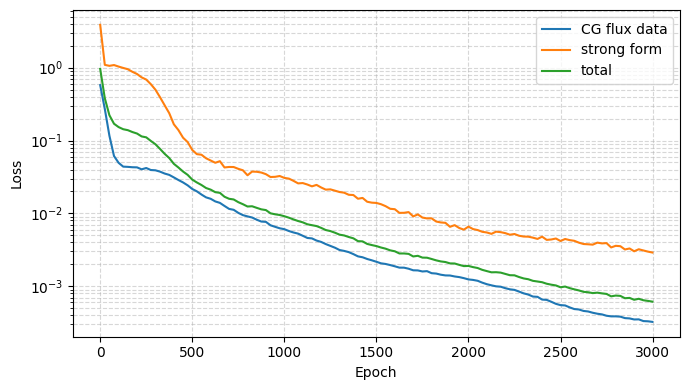

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(train_history["epoch"], train_history["data"], label="CG flux data")
plt.plot(train_history["epoch"], train_history["strong"], label="strong form")
plt.plot(train_history["epoch"], train_history["total"], label="total")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper functions required by the LCE / dual-CV analysis cells below
# ─────────────────────────────────────────────────────────────────────────────

def predict_q_rec_numpy(points):
    """Evaluate the trained q_rec network at physical points; return float64."""
    q_rec_net.eval()
    with torch.no_grad():
        xt = torch.as_tensor(np.asarray(points, dtype=np.float32), device=device)
        qt = q_rec_net(xt)
    return qt.cpu().numpy().astype(np.float64)


def lce_stats(lce_values):
    """Return max and mean absolute LCE."""
    v = np.abs(np.asarray(lce_values, dtype=np.float64))
    return {"max_abs": float(v.max()), "mean_abs": float(v.mean())}


def compute_local_conservation_errors(points_per_edge=6, source_degree=4):
    """Element-wise LCE: R_tau = ∮_∂tau q·n ds − ∫_tau f dΩ."""
    from numpy.polynomial.legendre import leggauss

    xi1d, wi1d = leggauss(points_per_edge)
    s_pts = 0.5 * (xi1d + 1.0)   # map Gauss nodes to [0, 1]
    s_wts = 0.5 * wi1d            # weights sum to 1

    # Reference-coordinate quadrature nodes on each edge of the standard triangle
    # (v0=(0,0), v1=(1,0), v2=(0,1)) — consistent with cell_edge_normals_and_lengths
    edge_ref = [
        np.column_stack([s_pts,               np.zeros_like(s_pts)]),   # edge 0: v0→v1
        np.column_stack([1.0 - s_pts,         s_pts]),                   # edge 1: v1→v2
        np.column_stack([np.zeros_like(s_pts), 1.0 - s_pts]),           # edge 2: v2→v0
    ]

    normals, lengths = cell_edge_normals_and_lengths()
    lce_cg  = np.zeros(num_cells, dtype=np.float64)
    lce_rec = np.zeros(num_cells, dtype=np.float64)

    for edge_id in range(3):
        X_ref_e  = edge_ref[edge_id]
        X_phys_e = map_reference_points_to_physical(X_ref_e)             # (C, G, 2)
        q_cg_e   = eval_cellwise_expression(q_cg_ufl, X_ref_e, gdim)    # (C, G, 2)
        q_rec_e  = predict_q_rec_numpy(
            X_phys_e.reshape(-1, gdim)
        ).reshape(num_cells, len(s_pts), gdim)

        n_e = normals[:, edge_id, :]   # (C, 2)  outward unit normals
        L_e = lengths[:, edge_id]      # (C,)    edge lengths

        qn_cg  = np.einsum("cgi,ci->cg", q_cg_e,  n_e)  # (C, G)
        qn_rec = np.einsum("cgi,ci->cg", q_rec_e, n_e)

        lce_cg  += L_e * (qn_cg  @ s_wts)
        lce_rec += L_e * (qn_rec @ s_wts)

    # Source integral ∫_tau f dΩ (same for both fluxes)
    X_ref_v, vol_wts = basix.make_quadrature(basix.CellType.triangle, source_degree)
    detJ   = cell_jacobian_determinants()
    f_cell = eval_cellwise_expression(f_func, X_ref_v, 1)[:, :, 0]   # (C, Gv)
    src    = detJ * (f_cell @ vol_wts)                                 # (C,)

    return {"lce_cg": lce_cg - src, "lce_rec": lce_rec - src}


def compute_dual_cv_conservation_errors(points_per_segment=6, source_degree=4):
    """Dual (vertex-centred) CV LCE for all interior vertices.

    For each interior vertex v the dual CV boundary inside cell c consists of
    two segments:  mid_prev → centroid  and  centroid → mid_next.
    The source contribution from cell c to vertex v's CV is (1/3)*∫_c f dΩ.
    """
    from numpy.polynomial.legendre import leggauss

    xi1d, wi1d = leggauss(points_per_segment)
    s_pts  = 0.5 * (xi1d + 1.0)
    s_wts  = 0.5 * wi1d
    n_gauss = len(s_pts)

    # Reference triangle geometry
    ref_v   = [np.array([0., 0.]), np.array([1., 0.]), np.array([0., 1.])]
    ref_mid = [0.5 * (ref_v[i] + ref_v[(i + 1) % 3]) for i in range(3)]
    cen_ref = np.array([1./3., 1./3.])

    # Build reference quadrature nodes for all 6 segment blocks:
    # block = li*2 + si,  li in {0,1,2},  si in {0,1}
    # si=0: mid_prev → centroid,  si=1: centroid → mid_next
    all_ref_pts = []
    for li in range(3):
        mid_next_r = ref_mid[li]
        mid_prev_r = ref_mid[(li - 1) % 3]
        for P_r, Q_r in [(mid_prev_r, cen_ref), (cen_ref, mid_next_r)]:
            pts = np.outer(1.0 - s_pts, P_r) + np.outer(s_pts, Q_r)
            all_ref_pts.append(pts)

    X_ref_all = np.vstack(all_ref_pts)   # (6*n_gauss, 2)

    # Evaluate fluxes for every cell at all 6 segment blocks simultaneously
    X_phys_all = map_reference_points_to_physical(X_ref_all)           # (C, 6G, 2)
    q_cg_all   = eval_cellwise_expression(q_cg_ufl, X_ref_all, gdim)  # (C, 6G, 2)
    q_rec_all  = predict_q_rec_numpy(
        X_phys_all.reshape(-1, gdim)
    ).reshape(num_cells, 6 * n_gauss, gdim)

    # Each vertex claims 1/3 of each adjacent cell's source integral
    X_ref_v, vol_wts = basix.make_quadrature(basix.CellType.triangle, source_degree)
    detJ            = cell_jacobian_determinants()
    f_cell          = eval_cellwise_expression(f_func, X_ref_v, 1)[:, :, 0]
    cell_src_third  = (1.0 / 3.0) * detJ * (f_cell @ vol_wts)

    # Build vertex-cell adjacency inline — avoids depending on vertex_cell_adjacency()
    # being defined in the global scope before this function is called.
    num_vertices = omega.topology.index_map(0).size_local
    adjacency = [[] for _ in range(num_vertices)]
    for _cid, _verts in enumerate(cell_vertices):
        for _lid, _vid in enumerate(_verts):
            if _vid < num_vertices:
                adjacency[int(_vid)].append((_cid, _lid))

    # Identify interior vertices (not on any boundary facet)
    omega.topology.create_connectivity(fdim, 0)
    ftv        = omega.topology.connectivity(fdim, 0)
    ext_facets = mesh.exterior_facet_indices(omega.topology)
    bdry_verts = set()
    for fid in ext_facets:
        for vid in ftv.links(int(fid)):
            bdry_verts.add(int(vid))

    interior = np.array(
        [v for v in range(num_vertices) if v not in bdry_verts and len(adjacency[v]) > 0],
        dtype=np.int32,
    )

    lce_cv_cg  = np.zeros(num_vertices, dtype=np.float64)
    lce_cv_rec = np.zeros(num_vertices, dtype=np.float64)

    for v in interior:
        v_pos    = omega_geometry[v]
        flux_cg  = flux_rec = src = 0.0

        for cell_id, local_id in adjacency[int(v)]:
            coords_c   = omega_geometry[cell_vertices[cell_id]]
            vi         = coords_c[local_id]
            cen_phys   = coords_c.mean(axis=0)
            mid_next_p = 0.5 * (vi + coords_c[(local_id + 1) % 3])
            mid_prev_p = 0.5 * (vi + coords_c[(local_id - 1) % 3])

            for si, (P, Q) in enumerate([(mid_prev_p, cen_phys), (cen_phys, mid_next_p)]):
                block = local_id * 2 + si
                sl    = slice(block * n_gauss, (block + 1) * n_gauss)

                qcg  = q_cg_all[cell_id,  sl, :]   # (G, 2)
                qrec = q_rec_all[cell_id, sl, :]

                L_seg = np.linalg.norm(Q - P)
                if L_seg < 1e-15:
                    continue
                tang  = (Q - P) / L_seg
                n_out = np.array([tang[1], -tang[0]])   # rotate -90° (right of travel)
                # Ensure n_out points away from vertex v (outward of dual CV)
                if np.dot(n_out, 0.5 * (P + Q) - v_pos) < 0:
                    n_out = -n_out

                flux_cg  += L_seg * np.dot(qcg  @ n_out, s_wts)
                flux_rec += L_seg * np.dot(qrec @ n_out, s_wts)

            src += cell_src_third[cell_id]

        lce_cv_cg[v]  = flux_cg  - src
        lce_cv_rec[v] = flux_rec - src

    return {"lce_cv_cg": lce_cv_cg, "lce_cv_rec": lce_cv_rec, "interior": interior}


print("LCE helper functions defined.")


LCE helper functions defined.


Element residual R_\tau stats, CG: {'max_abs': 0.000364356825709471, 'mean_abs': 0.00014242780127425494}
Element residual R_\tau stats, q_rec: {'max_abs': 5.0334404048316475e-05, 'mean_abs': 5.037530848125107e-06}
Interior dual-CV residual R_xi stats, CG: {'max_abs': 4.546393796492614e-08, 'mean_abs': 4.4707711634240724e-08}
Interior dual-CV residual R_xi stats, q_rec: {'max_abs': 7.895510513143504e-05, 'mean_abs': 9.747096342400383e-06}


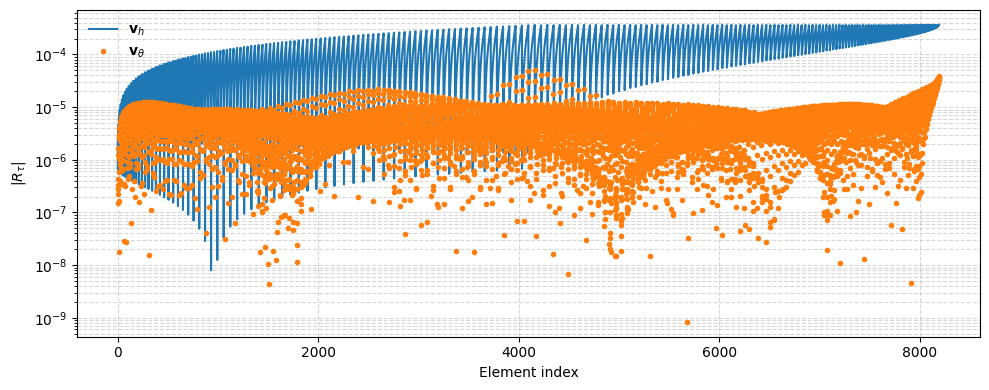

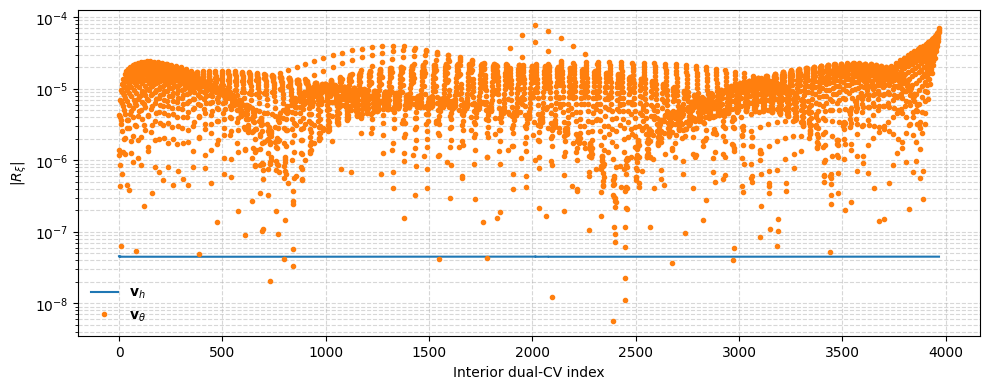

/tmp/ipykernel_2476331/1584607422.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


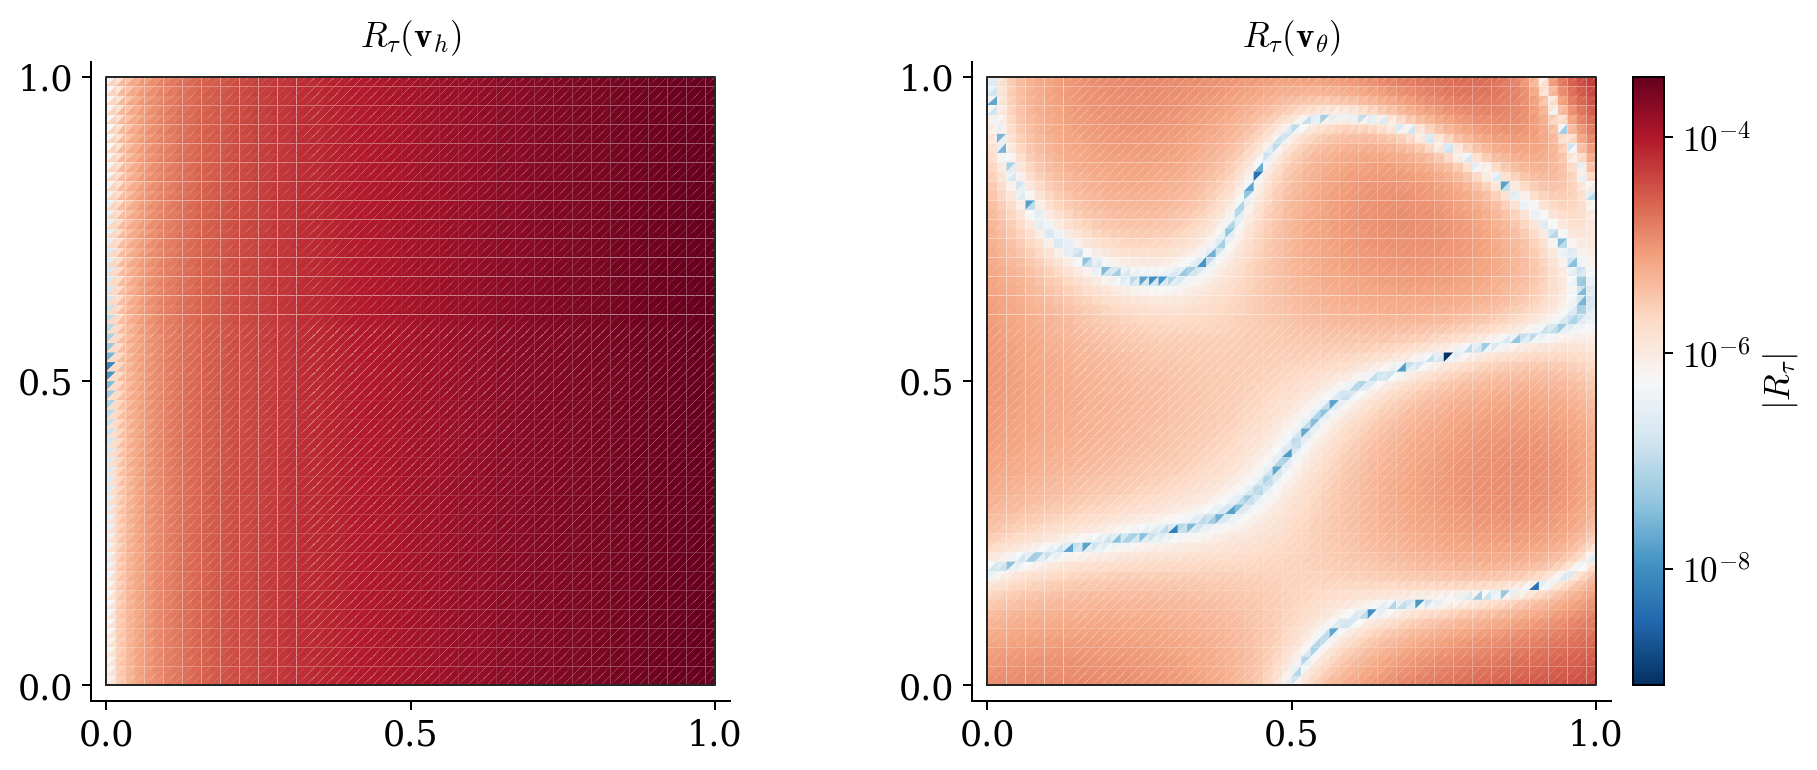

/tmp/ipykernel_2476331/1584607422.py:301: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


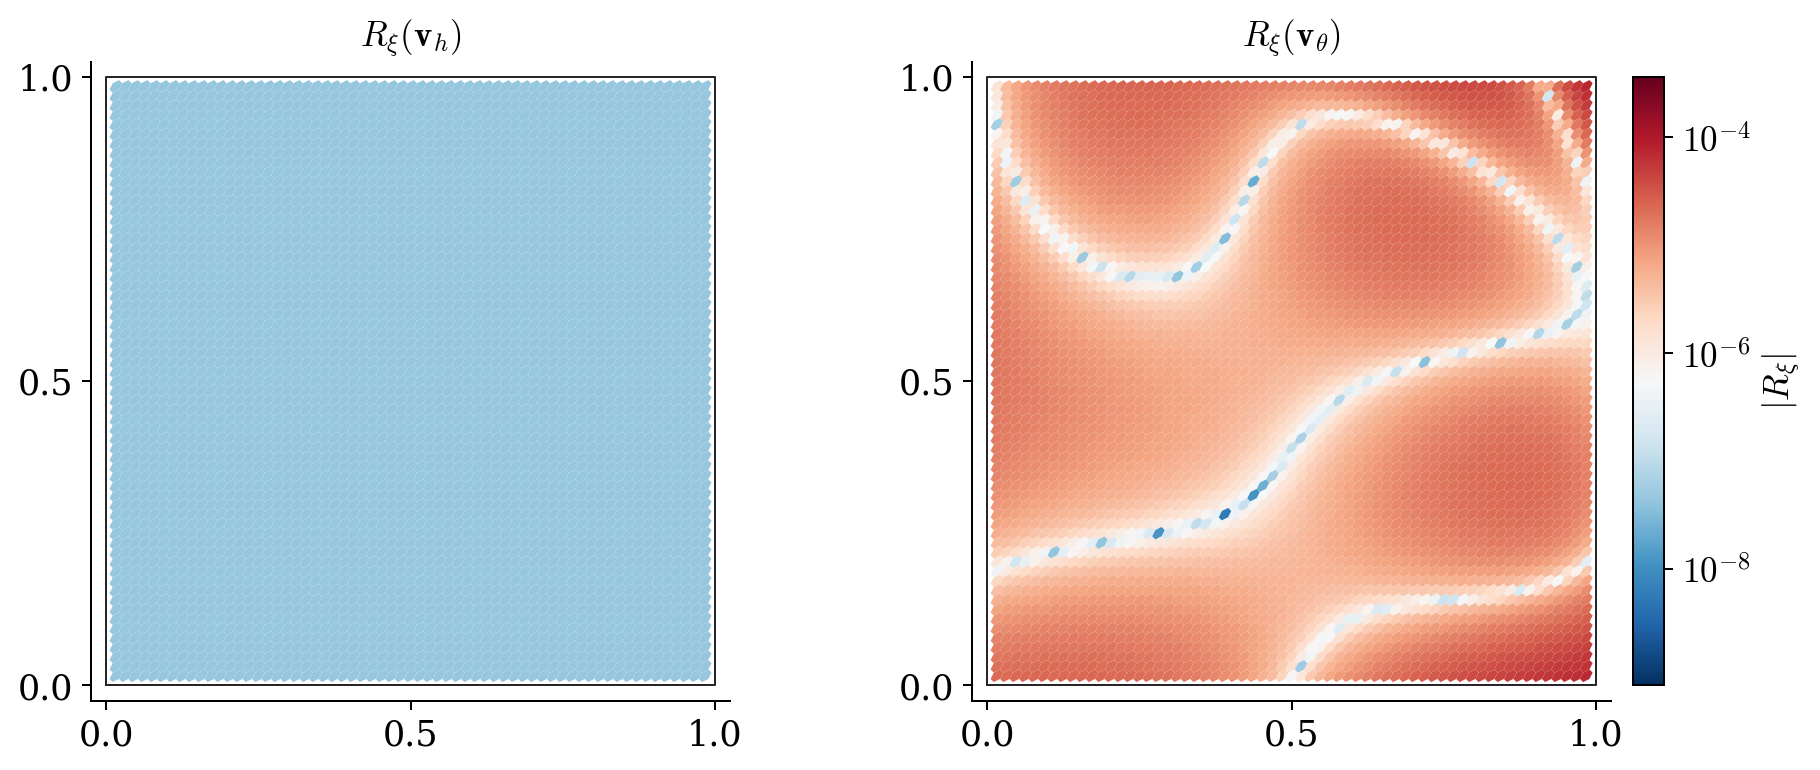

In [12]:
lce_results = compute_local_conservation_errors(
    points_per_edge=conservation_points_per_edge,
    source_degree=source_quadrature_degree,
)

cg_lce_stats = lce_stats(lce_results["lce_cg"])
q_rec_lce_stats = lce_stats(lce_results["lce_rec"])

cv_lce_results = compute_dual_cv_conservation_errors(
    points_per_segment=conservation_points_per_edge,
    source_degree=source_quadrature_degree,
)
interior_cv_ids = cv_lce_results["interior"]
cg_cv_lce_stats = lce_stats(cv_lce_results["lce_cv_cg"][interior_cv_ids])
q_rec_cv_lce_stats = lce_stats(cv_lce_results["lce_cv_rec"][interior_cv_ids])

print("Element residual R_\\tau stats, CG:", cg_lce_stats)
print("Element residual R_\\tau stats, q_rec:", q_rec_lce_stats)
print("Interior dual-CV residual R_xi stats, CG:", cg_cv_lce_stats)
print("Interior dual-CV residual R_xi stats, q_rec:", q_rec_cv_lce_stats)

plt.figure(figsize=(10, 4))
plt.plot(np.abs(lce_results["lce_cg"]), label=r"$\mathbf{v}_h$")
plt.plot(np.abs(lce_results["lce_rec"]), ".", label=r"$\mathbf{v}_\theta$")
plt.yscale("log")
plt.xlabel("Element index")
plt.ylabel(r"$|R_\tau|$")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(np.abs(cv_lce_results["lce_cv_cg"][interior_cv_ids]), label=r"$\mathbf{v}_h$")
plt.plot(np.abs(cv_lce_results["lce_cv_rec"][interior_cv_ids]), ".", label=r"$\mathbf{v}_\theta$")
plt.yscale("log")
plt.xlabel("Interior dual-CV index")
plt.ylabel(r"$|R_\xi|$")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Publication-style residual maps for element and dual-CV diagnostics
# ---------------------------------------------------------------------
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

RESIDUAL_ZERO_FLOOR = np.finfo(np.float64).tiny
RESIDUAL_CMAP = "RdBu_r"
RESIDUAL_MAP_FONTSIZE = 14
RESIDUAL_MAP_FIGSIZE = (10, 4.5)
RESIDUAL_COLORBAR_TICK_PARITY = "even"  # "even", "odd", or "all"
MAP_AXIS_PAD_FRACTION = 0.025
residual_log10_floor = RESIDUAL_ZERO_FLOOR


def residual_log10(values, floor=None):
    if floor is None:
        floor = residual_log10_floor
    values = np.asarray(values, dtype=np.float64)
    return np.log10(np.maximum(np.abs(values), floor))


def residual_abs_limits(*residual_arrays):
    abs_values = np.concatenate([
        np.ravel(np.abs(np.asarray(values, dtype=np.float64)))
        for values in residual_arrays
    ])
    abs_values = abs_values[np.isfinite(abs_values)]
    if abs_values.size == 0:
        return 1.0, 1.0

    positive_abs_values = abs_values[abs_values > 0.0]
    abs_min = positive_abs_values.min() if positive_abs_values.size else 1.0
    abs_max = max(abs_values.max(), abs_min)
    return float(abs_min), float(abs_max)


def common_residual_norm(*residual_arrays):
    abs_min, abs_max = residual_abs_limits(*residual_arrays)
    vmin = np.log10(abs_min)
    vmax = np.log10(abs_max)
    if np.isclose(vmin, vmax):
        vmin -= 0.5
        vmax += 0.5
    return abs_min, Normalize(vmin=float(vmin), vmax=float(vmax))


def residual_colorbar_ticks(norm, parity=RESIDUAL_COLORBAR_TICK_PARITY):
    first = int(np.ceil(norm.vmin))
    last = int(np.floor(norm.vmax))
    ticks_all = np.arange(first, last + 1, dtype=int)
    if parity == "even":
        ticks = ticks_all[(ticks_all % 2) == 0]
    elif parity == "odd":
        ticks = ticks_all[(ticks_all % 2) != 0]
    else:
        ticks = ticks_all
    ticks = ticks[(ticks >= norm.vmin) & (ticks <= norm.vmax)]
    if ticks.size < 2:
        ticks = ticks_all[(ticks_all >= norm.vmin) & (ticks_all <= norm.vmax)]
    if ticks.size < 2:
        return np.linspace(norm.vmin, norm.vmax, 3).tolist()
    return ticks.astype(float).tolist()


def residual_power_ticklabels(ticks):
    labels = []
    for tick in ticks:
        exponent = int(round(float(tick)))
        if np.isclose(float(tick), exponent):
            labels.append(rf"$10^{{{exponent}}}$")
        else:
            labels.append(rf"$10^{{{float(tick):.1f}}}$")
    return labels


def ordered_polygon(points):
    points = np.asarray(points, dtype=np.float64)
    center = np.mean(points, axis=0)
    angles = np.arctan2(points[:, 1] - center[1], points[:, 0] - center[0])
    return points[np.argsort(angles)]


def cell_polygons_for_plot():
    return [ordered_polygon(omega_geometry[verts]) for verts in cell_vertices]


def unique_points(points, decimals=14):
    unique = {}
    for point in points:
        key = tuple(np.round(point, decimals=decimals))
        unique[key] = np.asarray(point, dtype=np.float64)
    return np.asarray(list(unique.values()), dtype=np.float64)


def vertex_cell_adjacency():
    num_vertices = omega.topology.index_map(0).size_local
    adjacency = [[] for _ in range(num_vertices)]
    for cell_id, verts in enumerate(cell_vertices):
        for local_id, vertex_id in enumerate(verts):
            if vertex_id < num_vertices:
                adjacency[int(vertex_id)].append((cell_id, local_id))
    return adjacency


def dual_cv_polygons_for_plot(vertex_ids):
    adjacency = vertex_cell_adjacency()
    polygons = []

    for vertex_id in np.asarray(vertex_ids, dtype=np.int64):
        center = omega_geometry[vertex_id]
        boundary_points = []

        for cell_id, local_id in adjacency[int(vertex_id)]:
            verts = cell_vertices[cell_id]
            coords = omega_geometry[verts]
            vi = coords[local_id]
            centroid = np.mean(coords, axis=0)
            mid_next = 0.5 * (vi + coords[(local_id + 1) % 3])
            mid_prev = 0.5 * (vi + coords[(local_id - 1) % 3])
            boundary_points.extend([mid_next, centroid, mid_prev])

        points = unique_points(boundary_points)
        if len(points) < 3:
            polygons.append(points)
            continue

        angles = np.arctan2(points[:, 1] - center[1], points[:, 0] - center[0])
        polygons.append(points[np.argsort(angles)])

    return polygons


def set_map_axes(ax):
    xy_min = omega_geometry.min(axis=0)
    xy_max = omega_geometry.max(axis=0)
    span = xy_max - xy_min
    pad = MAP_AXIS_PAD_FRACTION * max(span)
    ax.set_xlim(xy_min[0] - pad, xy_max[0] + pad)
    ax.set_ylim(xy_min[1] - pad, xy_max[1] + pad)
    ax.set_aspect("equal")
    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.tick_params(labelsize=RESIDUAL_MAP_FONTSIZE)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_domain_outline(ax):
    xy_min = omega_geometry.min(axis=0)
    xy_max = omega_geometry.max(axis=0)
    outline = np.array([
        [xy_min[0], xy_min[1]],
        [xy_max[0], xy_min[1]],
        [xy_max[0], xy_max[1]],
        [xy_min[0], xy_max[1]],
        [xy_min[0], xy_min[1]],
    ])
    ax.plot(outline[:, 0], outline[:, 1], color="0.15", linewidth=0.8, zorder=3)


def add_residual_collection(ax, polygons, residuals, norm, title):
    collection = PolyCollection(
        polygons,
        array=residual_log10(residuals),
        cmap=RESIDUAL_CMAP,
        norm=norm,
        edgecolors="none",
        linewidths=0.0,
        rasterized=True,
        zorder=1,
    )
    ax.add_collection(collection)
    add_domain_outline(ax)
    set_map_axes(ax)
    ax.set_title(title, fontsize=RESIDUAL_MAP_FONTSIZE, pad=6)
    return collection


def domain_height_colorbar_axis(ax):
    xy_min = omega_geometry.min(axis=0)
    xy_max = omega_geometry.max(axis=0)
    span = xy_max - xy_min
    pad = MAP_AXIS_PAD_FRACTION * max(span)
    axis_height = span[1] + 2.0 * pad
    bottom_fraction = pad / axis_height
    height_fraction = span[1] / axis_height
    return inset_axes(
        ax,
        width="4.8%",
        height="100%",
        loc="lower left",
        bbox_to_anchor=(1.035, bottom_fraction, 1.0, height_fraction),
        bbox_transform=ax.transAxes,
        borderpad=0.0,
    )


map_style = {
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": RESIDUAL_MAP_FONTSIZE,
    "axes.titlesize": RESIDUAL_MAP_FONTSIZE,
    "axes.labelsize": RESIDUAL_MAP_FONTSIZE,
    "xtick.labelsize": RESIDUAL_MAP_FONTSIZE,
    "ytick.labelsize": RESIDUAL_MAP_FONTSIZE,
    "legend.fontsize": RESIDUAL_MAP_FONTSIZE,
    "axes.linewidth": 0.8,
}
residual_log10_floor, residual_norm = common_residual_norm(
    lce_results["lce_cg"],
    lce_results["lce_rec"],
    cv_lce_results["lce_cv_cg"][interior_cv_ids],
    cv_lce_results["lce_cv_rec"][interior_cv_ids],
)
colorbar_ticks = residual_colorbar_ticks(residual_norm)

with plt.rc_context(map_style):
    cell_polygons = cell_polygons_for_plot()
    fig, axes = plt.subplots(1, 2, figsize=RESIDUAL_MAP_FIGSIZE, dpi=180)
    mappable = add_residual_collection(
        axes[0], cell_polygons, lce_results["lce_cg"], residual_norm,
        r"$R_\tau(\mathbf{v}_h)$",
    )
    add_residual_collection(
        axes[1], cell_polygons, lce_results["lce_rec"], residual_norm,
        r"$R_\tau(\mathbf{v}_\theta)$",
    )
    cax = domain_height_colorbar_axis(axes[1])
    cbar = fig.colorbar(mappable, cax=cax, ticks=colorbar_ticks)
    cbar.set_label(r"$|R_\tau|$", fontsize=RESIDUAL_MAP_FONTSIZE)
    cbar.set_ticklabels(residual_power_ticklabels(colorbar_ticks))
    cbar.ax.tick_params(labelsize=RESIDUAL_MAP_FONTSIZE)
    fig.tight_layout()
    plt.show()

    cv_polygons_all = dual_cv_polygons_for_plot(interior_cv_ids)
    valid_cv_local_ids = [i for i, poly in enumerate(cv_polygons_all) if len(poly) >= 3]
    cv_polygons = [cv_polygons_all[i] for i in valid_cv_local_ids]
    cv_vertex_ids = interior_cv_ids[np.asarray(valid_cv_local_ids, dtype=np.int64)]

    fig, axes = plt.subplots(1, 2, figsize=RESIDUAL_MAP_FIGSIZE, dpi=180)
    mappable = add_residual_collection(
        axes[0], cv_polygons, cv_lce_results["lce_cv_cg"][cv_vertex_ids], residual_norm,
        r"$R_\xi(\mathbf{v}_h)$",
    )
    add_residual_collection(
        axes[1], cv_polygons, cv_lce_results["lce_cv_rec"][cv_vertex_ids], residual_norm,
        r"$R_\xi(\mathbf{v}_\theta)$",
    )
    cax = domain_height_colorbar_axis(axes[1])
    cbar = fig.colorbar(mappable, cax=cax, ticks=colorbar_ticks)
    cbar.set_label(r"$|R_\xi|$", fontsize=RESIDUAL_MAP_FONTSIZE)
    cbar.set_ticklabels(residual_power_ticklabels(colorbar_ticks))
    cbar.ax.tick_params(labelsize=RESIDUAL_MAP_FONTSIZE)
    fig.tight_layout()
    plt.show()


In [12]:
# ---------------------------------------------------------------------
# Flux L2 error against the manufactured exact flux
# ---------------------------------------------------------------------
def q_exact_numpy(points):
    """q = -k∇p,  k = 2x+1,  p = (x/2)y²."""
    points = np.asarray(points, dtype=np.float64)
    k = 2.0 * points[:, 0] + 1.0
    values = np.zeros((points.shape[0], gdim), dtype=np.float64)
    values[:, 0] = -k * 0.5 * points[:, 1] ** 2
    values[:, 1] = -k * points[:, 0] * points[:, 1]
    return values


def compute_flux_l2_errors(degree=5):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    detJ = cell_jacobian_determinants()

    X_cell = map_reference_points_to_physical(X_ref)
    X_flat = X_cell.reshape(-1, gdim)

    q_exact_cell = q_exact_numpy(X_flat).reshape(num_cells, len(X_ref), gdim)
    q_cg_cell = eval_cellwise_expression(q_cg_ufl, X_ref, gdim)
    q_rec_cell = predict_q_rec_numpy(X_flat).reshape(num_cells, len(X_ref), gdim)

    cg_sq = np.sum((q_cg_cell - q_exact_cell) ** 2, axis=2)
    rec_sq = np.sum((q_rec_cell - q_exact_cell) ** 2, axis=2)

    err_cg_sq_local = float(np.sum(detJ * (cg_sq @ weights)))
    err_rec_sq_local = float(np.sum(detJ * (rec_sq @ weights)))
    err_cg_sq = omega.comm.allreduce(err_cg_sq_local, op=MPI.SUM)
    err_rec_sq = omega.comm.allreduce(err_rec_sq_local, op=MPI.SUM)
    err_cg = math.sqrt(err_cg_sq)
    err_rec = math.sqrt(err_rec_sq)

    return {"q_cg_L2": err_cg, "q_rec_L2": err_rec}


l2_errors = compute_flux_l2_errors(degree=l2_quadrature_degree)
print("Flux L2 error before correction (CG):", l2_errors["q_cg_L2"])
print("Flux L2 error after correction (direct q_rec):", l2_errors["q_rec_L2"])
print("Improvement factor q_CG/q_rec:", l2_errors["q_cg_L2"] / l2_errors["q_rec_L2"])

Flux L2 error before correction (CG): 0.014783648788452943
Flux L2 error after correction (direct q_rec): 0.01958491685907071
Improvement factor q_CG/q_rec: 0.754848687632081


In [13]:
# ---------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------
current_cg_context = {
    "ref": ref,
    "omega": omega,
    "V": V,
    "p_sol": p_sol,
    "k_m": k_m,
    "f_func": f_func,
    "h": h,
    "dofs": V.dofmap.index_map.size_global,
}

current_p_cg_l2 = compute_pressure_l2_error_on_mesh(current_cg_context, degree=l2_quadrature_degree)

if MPI.COMM_WORLD.rank == 0:
    print("=" * 72)
    print(f"  2D q_rec PINN + CG — no fracture, ref={ref}")
    print("=" * 72)
    print(f"  h                      = {h:.6e}")
    print(f"  DOFs in V              = {V.dofmap.index_map.size_global}")
    print(f"  CG flux data points    = {X_data.shape[0]:,}")
    print(f"  Strong-form points     = {X_strong.shape[0]:,}")
    print(f"  Boundary pts / edge    = {boundary_points_per_edge}")
    print(f"  CG solve time          = {hybrid_timings['cg_solve']:.6f} s")
    print(f"  CG flux collect time   = {hybrid_timings['flux_collection']:.6f} s")
    print(f"  q_rec PINN time        = {hybrid_timings['pinn_reconstruction']:.6f} s")
    print(f"  Total hybrid time      = {hybrid_timings['total_hybrid']:.6f} s")
    print(f"  ||p_CG - p_exact||_L2  = {current_p_cg_l2:.6e}")
    print(f"  ||q_CG - q_exact||_L2  = {l2_errors['q_cg_L2']:.6e}")
    print(f"  ||q_rec - q_exact||_L2 = {l2_errors['q_rec_L2']:.6e}")
    print(f"  q_CG / q_rec improve   = {l2_errors['q_cg_L2'] / l2_errors['q_rec_L2']:.6f}")
    print(f"  max  |R_\\tau| CG          = {cg_lce_stats['max_abs']:.6e}")
    print(f"  max  |R_\\tau| q_rec       = {q_rec_lce_stats['max_abs']:.6e}")
    print(f"  mean |R_\\tau| CG          = {cg_lce_stats['mean_abs']:.6e}")
    print(f"  mean |R_\\tau| q_rec       = {q_rec_lce_stats['mean_abs']:.6e}")
    print(f"  max  |R_xi| CG int     = {cg_cv_lce_stats['max_abs']:.6e}")
    print(f"  max  |R_xi| q_rec int  = {q_rec_cv_lce_stats['max_abs']:.6e}")
    print(f"  mean |R_xi| CG int     = {cg_cv_lce_stats['mean_abs']:.6e}")
    print(f"  mean |R_xi| q_rec int  = {q_rec_cv_lce_stats['mean_abs']:.6e}")
    cg_pinn_metrics = [
        ("Time (s)", hybrid_timings["total_hybrid"], ".2f"),
        ("||p - p_exact||_L2", current_p_cg_l2, ".3e"),
        ("||v - v_exact||_L2", l2_errors["q_rec_L2"], ".3e"),
        ("max_tau |R_\\tau|", q_rec_lce_stats["max_abs"], ".3e"),
        ("mean_tau |R_\\tau|", q_rec_lce_stats["mean_abs"], ".3e"),
    ]
    print("")
    print("CG+PINN metrics for comparison table:")
    print(f"{'Metric':<28} {'CG+PINN':>14}")
    print("-" * 43)
    for metric, value, fmt in cg_pinn_metrics:
        print(f"{metric:<28} {format(float(value), fmt):>14}")
    print("=" * 72)


  2D q_rec PINN + CG — no fracture, ref=6
  h                      = 1.562500e-02
  DOFs in V              = 4225
  CG flux data points    = 81,920
  Strong-form points     = 8,192
  Boundary pts / edge    = 3
  CG solve time          = 1.337316 s
  CG flux collect time   = 0.109543 s
  q_rec PINN time        = 42.783068 s
  Total hybrid time      = 44.229927 s
  ||p_CG - p_exact||_L2  = 3.030237e-05
  ||q_CG - q_exact||_L2  = 1.478365e-02
  ||q_rec - q_exact||_L2 = 1.958492e-02
  q_CG / q_rec improve   = 0.754849
  max  |R_\tau| CG          = 3.643568e-04
  max  |R_\tau| q_rec       = 5.033440e-05
  mean |R_\tau| CG          = 1.424278e-04
  mean |R_\tau| q_rec       = 5.037531e-06
  max  |R_xi| CG int     = 4.546394e-08
  max  |R_xi| q_rec int  = 7.895511e-05
  mean |R_xi| CG int     = 4.470771e-08
  mean |R_xi| q_rec int  = 9.747096e-06

CG+PINN metrics for comparison table:
Metric                              CG+PINN
-------------------------------------------
Time (s)             

In [14]:
# ========================================================================
#   2D q_rec PINN + CG — no fracture, ref=4
# ========================================================================
#   h                      = 6.250000e-02
#   DOFs in V              = 289
#   CG flux data points    = 5,120
#   Strong-form points     = 512
#   Boundary pts / edge    = 3
#   CG solve time          = 0.200577 s
#   CG flux collect time   = 1.044427 s
#   q_rec PINN time        = 22.314146 s
#   Total hybrid time      = 23.559150 s
#   ||p_CG - p_exact||_L2  = 6.769576e-04
#   ||q_CG - q_exact||_L2  = 3.402181e-02
#   ||q_rec - q_exact||_L2 = 1.883462e-02
#   q_CG / q_rec improve   = 1.806344
#   max  |R_i| CG          = 3.837277e-03
#   max  |R_i| q_rec       = 4.028652e-04
#   mean |R_i| CG          = 1.309037e-03
#   mean |R_i| q_rec       = 5.371137e-05
# ========================================================================